In [2]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, print_wise, get_lagplot
from useful_stuff.general_utils.RSA import  dRSA
from useful_stuff.general_utils.regression import  dyn_linear_encoding
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from general_utils.II import dynInformationImbalance
from project_specific_utils.dataloader import load_meg_data, load_eyetracking_data
from project_specific_utils.utils import get_spaced_pseudotrials
from image_processing.gaze_dep_models import save_ANN_features


In [3]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 3
    run = 1
    neu_fs = 100
    gaze_fs = 50
    mod_fs = 23.976
    sq_side = 384
    sensors_group = 'occ'
    model_name = "vit_l_16"
    full_model_name = "alexnet_features.4"
    time_points = 600
    pseudotrials_n = 50
    max_lag = 200
    iterations_n = 100
    repetition = 0
    RDM_metric = "correlation"
    pkg = 'timm'
    regr_out_eyes = True
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, cfg.pkg)

In [4]:
def plot_rsa(tot_rsa, neu_fs, max_lag, title=None, tick_step=20):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    # --- heatmap ---
    ax[0].imshow(tot_rsa)

    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ticks_labels = np.round(ticks / neu_fs, 2)
    ticks += max_lag

    # --- lag plot ---
    lagplot = get_lagplot(tot_rsa, max_lag=max_lag)
    ax[1].plot(lagplot)

    ax[1].set_ylabel("dRSA similarity")
    ax[1].set_xlabel("lag [sec]")
    ax[1].set_xticks(ticks, ticks_labels)
    ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)

    # --- 🔥 compute peak ---
    peak_idx = np.argmax(lagplot)
    peak_val = lagplot[peak_idx]
    peak_lag = (peak_idx - max_lag) / neu_fs  # convert to seconds

    # --- 🔥 textbox ---
    textstr = f"magnitude: {peak_val:.3f}\nlag: {peak_lag:.2f}s"
    ax[1].text(
        0.05, 0.95, textstr,
        transform=ax[1].transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
    )

    # --- labels ---
    ax[0].set_xlabel(f"Model time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_ylabel(f"Neural time, length={tot_rsa.shape[1]/neu_fs}sec")
    ax[0].set_xticks([])
    ax[0].set_yticks([])

    fig.suptitle(title, fontsize=20)
    plt.tight_layout()



In [ ]:
def subsampling_II(neu_trials, mod_trials, neu_metric, mod_metric, k=1):
    II_obj = dynInformationImbalance(neu_metric, mod_metric, k=k)
    II_obj.compute_both_RDM_timeseries(neu_trials, mod_trials)
    II_obj.compute_both_distance_ranks_timeseries()
    II_A2B, II_B2A = II_obj.compute_both_dynII()
    return II_A2B, II_B2A
# EOF
def subsampling_RSA(neu_trials, mod_trials, neu_metric, mod_metric, RSA_metric="correlation"):
    drsa_obj_corr = dRSA(neu_metric, model_RDM_metric=mod_metric, RSA_metric=RSA_metric)
    drsa_obj_corr.compute_both_RDM_timeseries(neu_trials, mod_trials)
    rsa_corr = drsa_obj_corr.compute_dRSA()
    return rsa_corr
# EOF
def subsampling_encoding(neu_trials, mod_trials, regression_type, cv_type, max_lag, score_type='r2', n_splits=5):
    regression_obj = dyn_linear_encoding(regression_type, cv_type, max_lag, score_type=score_type, n_splits=n_splits)
    final_score = regression_obj.crossvalidate_general_dyn(mod_trials, neu_trials)
    print(final_score.shape())
    return final_score.get_array()
# EOF 
def compatible_TimeSeries_check(X, Y):
    if len(X) != len(Y):
        raise ValueError(f"X and Y TimeSeries must have the same length, got {len(X)} and {len(Y)}. ")
    if X.get_fs() != Y.get_fs():
        raise ValueError(f"X and Y TimeSeries must have the same sampling frequency, got X_fs={X.get_fs()} and Y_fs={Y.get_fs()}.")
# EOF 

def subsampling_lagged_comparisons(measure, signal, model, pseudotrials_len_tps, iteration_n, pseudotrials_n, func, rank, *args, min_separation=5, **kwargs):
    compatible_TimeSeries_check(signal, model)    
    if measure=='RSA':
        tot_similarity = np.zeros((pseudotrials_len_tps, pseudotrials_len_tps))
    elif measure=='II':
        tot_similarity_A2B = np.zeros((pseudotrials_len_tps, pseudotrials_len_tps))
        tot_similarity_B2A = np.zeros((pseudotrials_len_tps, pseudotrials_len_tps))
    elif measure=='encoding':
        # depending on which score we'll use the output will change its shape
        if kwargs["score_type"]=='r2':
            D = signal.shape()[0]
            tot_similarity = np.zeros((D, args[2]*2+1)) # args[2] should be the maxlag
        elif kwargs["score_type"]=='corr':
            tot_similarity = np.zeros((1,args[2]*2+1))
        # end if kwargs["score_type"]=='r2':
    # end if measure=='RSA':
    for i_iter in range(iteration_n):
        if i_iter %10 ==0:
            print_wise(f"starting iteration {i_iter} of {iteration_n-1}", rank=rank)
        signal_trials = []
        model_trials = []
        pseudotrials_idx = get_spaced_pseudotrials(signal, pseudotrials_len_tps, pseudotrials_n, min_separation)
        for n in pseudotrials_idx:
            signal_trials.append(signal.get_array()[:,n:n+pseudotrials_len_tps])
            model_trials.append(model.get_array()[:,n:n+pseudotrials_len_tps])
        # end for n in pseudotrials_idx:
        signal_trials = TimeSeries(np.stack(signal_trials, axis=2), cfg.neu_fs)
        model_trials = TimeSeries(np.stack(model_trials, axis=2), cfg.neu_fs)
        if measure != "II":
            similarity_corr = func(signal_trials, model_trials, *args, **kwargs)    
            tot_similarity += similarity_corr
        else: 
            similarity_corr_A2B, similarity_corr_B2A = func(signal_trials, model_trials, *args, **kwargs)    
            tot_similarity_A2B += similarity_corr_A2B
            tot_similarity_B2A += similarity_corr_B2A
        # end if measure != "II":
    # end for i_iter in range(iteration_n):
    if measure != "II":
        tot_similarity = tot_similarity/iteration_n
        return tot_similarity
    else:
        tot_similarity_A2B = tot_similarity_A2B/iteration_n
        tot_similarity_B2A = tot_similarity_B2A/iteration_n
        return tot_similarity_A2B, tot_similarity_B2A
    # end if measure != "II":

# EOF

In [6]:
mod = []
len_mod = []
for i_run in range(1,4):
    model_filename = save_ANN_features(paths, cfg.full_model_name, cfg.mod_fs, cfg.sub_num, i_run + 3*cfg.repetition, 1000, cfg.sq_side, 'all')
    with h5py.File(model_filename, "r") as f:
        run_mod = f['vecrep'][:]
    # end with h5py.File(model_filename, "r") as f:
    run_mod = TimeSeries(run_mod, cfg.mod_fs)
    run_mod.resample(cfg.neu_fs)
    len_mod.append(len(run_mod)) 
    mod.append(run_mod.get_array())
# end for i_run in range(1,4):
mod = TimeSeries(np.concatenate(mod, axis=1), cfg.neu_fs)


In [7]:
neu = []
print(f"Regressing out eyes: {cfg.regr_out_eyes}")
for i_run in range(1,4):
    run_neu, labels = load_meg_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.sensors_group, cfg.neu_fs)
    run_neu.z_score_feats()
    # run_neu, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
    # run_neu.resample(cfg.neu_fs)
    if cfg.regr_out_eyes:
        run_gaze, _ = load_eyetracking_data(paths, cfg.sub_num, i_run + 3*cfg.repetition, cfg.gaze_fs, xy=True)
        run_gaze.z_score_feats()
        run_gaze.resample(cfg.neu_fs)
        min_len = min(len(run_gaze), len(run_neu))
        run_gaze = TimeSeries(run_gaze[:min_len], run_gaze.get_fs())
        run_neu = TimeSeries(run_neu[:min_len], run_neu.get_fs())
        dyn_regr_obj = dyn_linear_encoding('lr', 'same', None)
        # y_regress_out = dyn_regr_obj.pointwise_regress_out(run_gaze,run_neu, regression_type=None)
        y_regress_out, _ = dyn_regr_obj.delay_embed_PCR_regress_out(run_gaze, run_neu, (-100, 100), PCs_to_keep=50, pad_mode='edge', crop_end=True)
        neu.append(y_regress_out[:len_mod[i_run-1]])
    else: 
        neu.append(run_neu[:len_mod[i_run-1]])
    # end if cfg.regr_out_eyes:
# end for i_run in range(1,4):
neu = TimeSeries(np.concatenate(neu, axis=1), cfg.neu_fs)

Regressing out eyes: True


In [16]:
tot_rsa = subsampling_lagged_comparisons('RSA', neu, mod, cfg.time_points, cfg.iterations_n - 50, cfg.pseudotrials_n, subsampling_RSA, 0, *(cfg.RDM_metric, cfg.RDM_metric),)

12:12:15 - rank 0 starting iteration 0 of 49
12:12:19 - rank 0 starting iteration 10 of 49
12:12:24 - rank 0 starting iteration 20 of 49
12:12:29 - rank 0 starting iteration 30 of 49
12:12:33 - rank 0 starting iteration 40 of 49


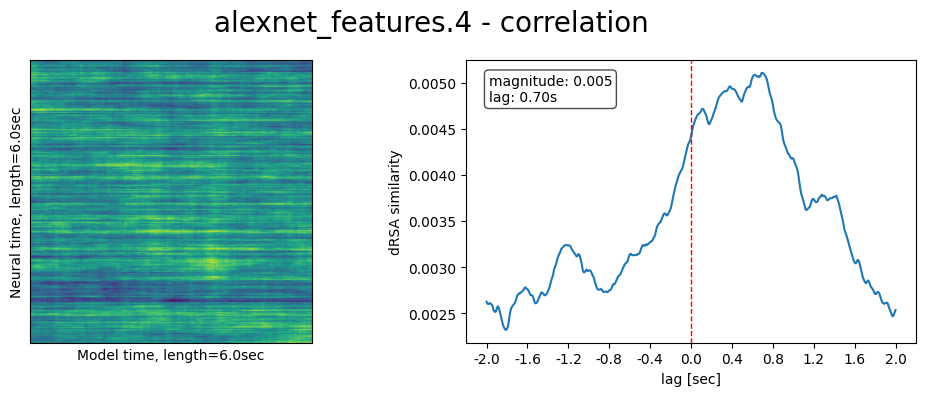

In [17]:
plot_rsa(tot_rsa, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)

In [22]:
tot_II_A2B, tot_II_B2A = subsampling_lagged_comparisons('II', neu, mod, cfg.time_points, cfg.iterations_n - 50, cfg.pseudotrials_n, subsampling_II, 0, *(cfg.RDM_metric, cfg.RDM_metric),**{"k": 20})

12:16:39 - rank 0 starting iteration 0 of 49
12:17:26 - rank 0 starting iteration 10 of 49
12:18:12 - rank 0 starting iteration 20 of 49
12:18:58 - rank 0 starting iteration 30 of 49
12:19:44 - rank 0 starting iteration 40 of 49


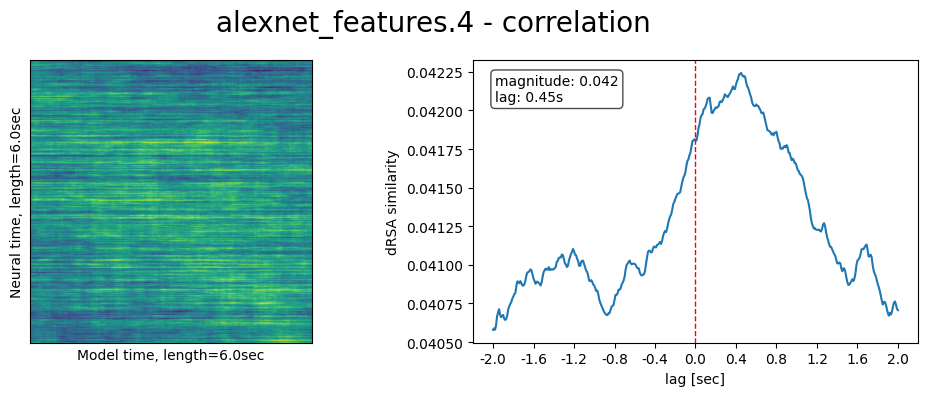

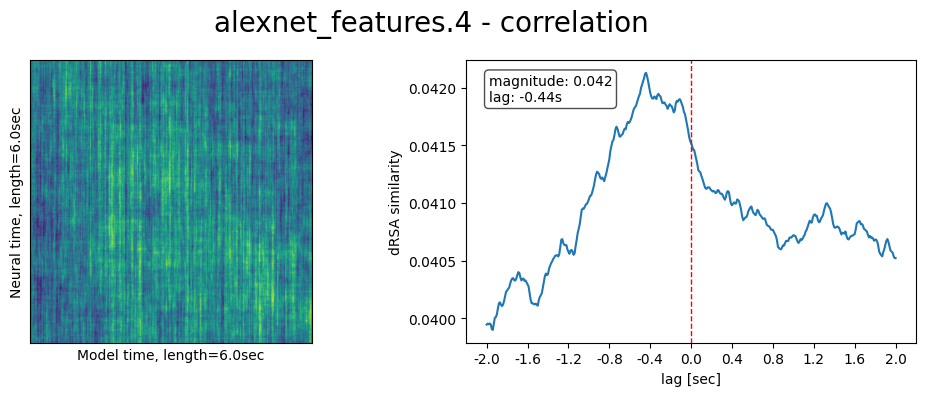

In [ ]:
plot_rsa(1-tot_II_A2B, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40)
plot_rsa(1-tot_II_B2A, cfg.neu_fs, cfg.max_lag, f"{cfg.full_model_name} - {cfg.RDM_metric}", tick_step=40) #TODO check if the dynII is correct in its timecourse...

In [27]:
print(cfg.pseudotrials_n)

50


In [ ]:
r = subsampling_lagged_comparisons('encoding', neu, mod, cfg.time_points, cfg.iterations_n - 99, cfg.pseudotrials_n, subsampling_encoding, 0, *('ridge', 'kf', 5),**{"score_type": "corr", "n_splits": 2, }) 

12:40:25 - rank 0 starting iteration 0 of 0
(1, 11)


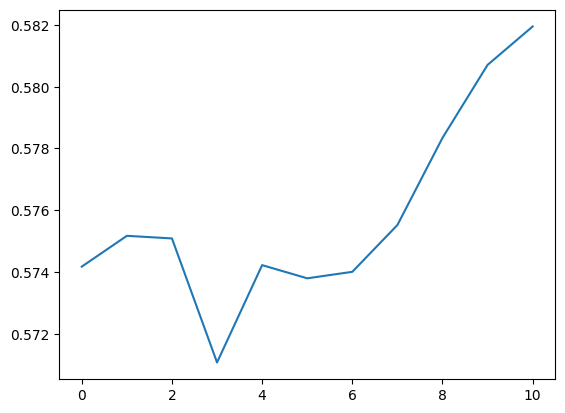

In [47]:
plt.plot(r.T);